# Breast Cancer Model Training and Testing

This notebook follows the EDA workflow and adds preprocessing, model training, evaluation, and model saving.

# Import libraries


In [1]:
import warnings                                                                          #handle warning msgs
warnings.filterwarnings('ignore')                                                        #suppresses warning

import numpy as np                                                                       #numerical operations
import pandas as pd                                                                      #data manipulation
import matplotlib.pyplot as plt                                                          #plotting library
import seaborn as sns                                                                    #advanced visualization
import joblib                                                                            #save and train model
from pathlib import Path                                                                 #manage file path

from sklearn.compose import ColumnTransformer                                            #scale numerical data and encode categorical data
from sklearn.impute import SimpleImputer                                                 #handles missing values (mean,median)
from sklearn.metrics import(
    accuracy_score,                                                                      # % of correct prediction
    classification_report,                                                               #shows precision,recall,f1-score together
    confusion_matrix,                                                                    #shows prediction vs actual values in matrix form
    f1_score,                                                                            #balance of precision and recall
    precision_score,                                                                     #predicted + are correct
    recall_score,                                                                        #actual + are correctly identified
    roc_auc_score,                                                                       #measures overall model performance
    roc_curve,                                                                           #plots true+ and false+ rate
)
from sklearn.model_selection import cross_val_score,train_test_split                     #cv to evaluate model performance #splits dataset into training and testing set
from sklearn.pipeline import Pipeline                                                    #preprocessing + model
from sklearn.preprocessing import OneHotEncoder,StandardScaler                           #converts categorical variables into binary columns
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

sns.set_style('whitegrid')
RANDOM_STATE=42

from sklearn.preprocessing import OrdinalEncoder                                          #converts categories into ordered numbers
from sklearn.model_selection import GridSearchCV                                          #finds best hyperparameters automatically
from sklearn.metrics import precision_recall_curve,auc                                    #tradeoff btw p & r   #calculate area under any curve

# load data

In [2]:
df = pd.read_csv('data/data.csv')
df.head()

,Age,Gender,Protein1,Protein2,Protein3,Protein4,Tumour_Stage,Histology,ER status,PR status,HER2 status,Surgery_type,Date_of_Surgery,Date_of_Last_Visit,Patient_Status
0,42,FEMALE,0.95256,2.15000,0.007972,-0.048340,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,20-May-18,26-Aug-18,Alive
1,54,FEMALE,0.00000,1.38020,-0.498030,-0.507320,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,26-Apr-18,25-Jan-19,Dead
2,63,FEMALE,-0.52303,1.76400,-0.370190,0.010815,II,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Lumpectomy,24-Aug-18,08-Apr-20,Alive
3,78,FEMALE,-0.87618,0.12943,-0.370380,0.132190,I,Infiltrating Ductal Carcinoma,Positive,Positive,Negative,Other,16-Nov-18,28-Jul-20,Alive
4,42,FEMALE,0.22611,1.74910,-0.543970,-0.390210,II,Infiltrating Ductal Carcinoma,Positive,Positive,Positive,Lumpectomy,12-Dec-18,05-Jan-19,Alive


In [3]:
#check dimension of dataset
df.shape

(334, 15)

In [4]:
#summary of dataframe structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 334 non-null    int64  
 1   Gender              334 non-null    object 
 2   Protein1            334 non-null    float64
 3   Protein2            334 non-null    float64
 4   Protein3            334 non-null    float64
 5   Protein4            334 non-null    float64
 6   Tumour_Stage        334 non-null    object 
 7   Histology           334 non-null    object 
 8   ER status           334 non-null    object 
 9   PR status           334 non-null    object 
 10  HER2 status         334 non-null    object 
 11  Surgery_type        334 non-null    object 
 12  Date_of_Surgery     334 non-null    object 
 13  Date_of_Last_Visit  317 non-null    object 
 14  Patient_Status      321 non-null    object 
dtypes: float64(4), int64(1), object(10)
memory usage: 39.3+ K

## Data Cleaning

✔ Cleans target variable (Patient_Status)
✔ Handles invalid protein values
✔ Converts dates properly
✔ Creates new feature (Followup_Days)
✔ Prepares data for ML

In [5]:
# Create a copy of the dataset to avoid modifying original data
df = df.copy()
# Clean Patient_Status column (remove spaces and standardize text)
df['Patient_Status'] = df['Patient_Status'].astype(str).str.strip()
# Replace invalid or empty values with NaN
df['Patient_Status'] = df['Patient_Status'].replace({'':np.NAN,'nan':np.nan,'NAN':np.nan})
# Drop rows where Patient_Status is missing
df = df.dropna(subset=['Patient_Status']).copy()
# Standardize labels (Alive / Dead)
df['Patient_Status'] = df['Patient_Status'].str.capitalize()

# Handle Protein Columns


protein_cols = ['Protein1','Protein2','Protein3','Protein4']
df[protein_cols] = df[protein_cols].replace(0,np.nan)

# Handle Date Columns

date_cols = ['Date_of_Surgery','Date_of_Last_Visit']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Feature Engineering

df['Followup_Days'] = (df['Date_of_Last_Visit']-df['Date_of_Surgery']).dt.days
df = df.drop(columns=date_cols)

# Missing Values Summary

df.isnull().sum()



Age               0
Gender            0
Protein1          2
Protein2          0
Protein3          0
Protein4          1
Tumour_Stage      0
Histology         0
ER status         0
PR status         0
HER2 status       0
Surgery_type      0
Patient_Status    0
Followup_Days     4
dtype: int64

In [6]:
df['Patient_Status'].value_counts()

Patient_Status
Alive    255
Dead      66
Name: count, dtype: int64

## Feature and Target Split

✔ Separates features (X) and target (y)
✔ Converts labels into numeric format for ML
✔ Validates that no unexpected labels exist
✔ Identifies numeric vs categorical features
✔ Prepares data for preprocessing pipeline

In [7]:
# Split Features (X) and Target (y)
X = df.drop(columns=['Patient_Status'])
y = df['Patient_Status'].map({'Alive':1,'Dead':0})

# Validate Target Values

if y.isnull().any():
    invalid_labels = sorted(df.loc[y.isnull(),'Patient_Status'].dropna().unique().tolist())
    raise ValueError(f'Unexpected labels found in Patient_Status:{invalid_labels}')

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Display Feature Information

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)
print('Target missing values:', y.isnull().sum())

Numeric features: ['Age', 'Protein1', 'Protein2', 'Protein3', 'Protein4', 'Followup_Days']
Categorical features: ['Gender', 'Tumour_Stage', 'Histology', 'ER status', 'PR status', 'HER2 status', 'Surgery_type']
Target missing values: 0


✔ Splits dataset into training and testing sets
✔ Maintains class balance using stratification
✔ Ensures reproducibility
✔ Helps verify data sizes before training

In [8]:
# Split Data into Training & Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Check Shapes of Split Data

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (256, 13)
X_test : (65, 13)
y_train: (256,)
y_test : (65,)


✔ Creates a folder to store model files
✔ Saves feature column order
✔ Ensures future predictions use correct input format

In [9]:
# Create Artifacts Directory

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

# Save Feature Columns

feature_columns = X.columns.tolist()
joblib.dump(feature_columns, artifacts_dir / 'feature_columns.pkl')   

['artifacts\\feature_columns.pkl']

## Preprocessing Pipeline

✔ Handles missing values
✔ Encodes categorical data
✔ Scales numerical data
✔ Keeps everything organized
✔ Prevents data leakage (when used with Pipeline)  

In [10]:
# Numeric Data Transformation Pipeline

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical Data Transformation Pipeline

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Both Pipelines

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Display Preprocessor Structure

preprocessor  

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

✔ Correct separation of ordinal vs nominal
✔ Proper encoding strategy
✔ Improved model understanding
✔ Ready for production with small fixes   

In [11]:
# Define the order for the stages
stage_order = [['I', 'II', 'III']]

# Split your categorical features
ordinal_features = ['Tumour_Stage']
# All other categorical features are nominal (no inherent order)
nominal_features = ['Gender', 'Histology', 'ER status', 'PR status', 'HER2 status', 'Surgery_type']

# Create the new preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num' , numeric_transformer, numeric_features),
    ('ord', OrdinalEncoder(categories=stage_order), ordinal_features),
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_features)
])

print("Preprocessor updated with Ordinal Encoding for Tumour_Stage.")

Preprocessor updated with Ordinal Encoding for Tumour_Stage.


# class distribution (in %)

✔ Calculates percentage of each class
✔ Helps detect imbalance in dataset
✔ Highlights need for better evaluation metrics

In [12]:
# Calculate Class Distribution

class_distribution = df['Patient_Status'].value_counts(normalize=True).mul(100).round(2)

# Display Results

print('Class distribution (%):')
print(class_distribution)
print()

# Important Insight

print('AUC, recall, and F1-score are important here because the classes are imbalanced.')

Class distribution (%):
Patient_Status
Alive    79.44
Dead     20.56
Name: proportion, dtype: float64

AUC, recall, and F1-score are important here because the classes are imbalanced.


## Model Training

Logistic Regression → baseline linear model
Decision Tree → interpretable
Random Forest → strong ensemble
KNN → distance-based


✔ Trains multiple ML models
✔ Uses pipeline (preprocessing + model)
✔ Evaluates using:
    *  Accuracy
    *  Precision
    *  Recall
    *  F1-score
    *  Cross-validation
✔ Stores all results in a structured table
✔ Fair comparison across models
✔ Prevents leakage
✔ Uses proper evaluation metrics
✔ Stores reusable trained models
✔ Gives ranked results

In [13]:
# Define Models to Train

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7)
}

results = []
trained_models = {}

# Train and Evaluate Each Model

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')

 # Store Model Performance Metrics

    results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Test Recall': recall_score(y_test, y_test_pred, zero_division=0),
        'Test F1': f1_score(y_test, y_test_pred, zero_division=0),
        'CV F1 Mean': cv_scores.mean()
    })
    trained_models[name] = pipeline

# Create Results DataFrame

results_df = (
    pd.DataFrame(results)
    .sort_values(by=['Test F1', 'Test Accuracy'], ascending=False)
    .reset_index(drop=True)
)

# Display Results

results_df.round(4)

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,CV F1 Mean
0,Logistic Regression,0.7930,0.8000,0.8000,1.0000,0.8889,0.8845
1,KNN,0.7773,0.8000,0.8000,1.0000,0.8889,0.8546
2,Random Forest,1.0000,0.7846,0.7969,0.9808,0.8793,0.8840
3,Decision Tree,1.0000,0.6154,0.7755,0.7308,0.7525,0.7459


For each model:

✔ If Train ≈ Test

→ Good generalization ✅

❌If Train >> Test

→ Overfitting ❌
(model memorizes training data)

❌ If both low

→ Underfitting ❌
(model too simple)

✔ Good visualization choice
✔ Needs column filtering fix
✔ Prefer F1/ROC-AUC for imbalance
✔ Converts data into plot-friendly format
✔ Compares training vs testing accuracy
✔ Helps detect:
   * Overfitting (Train >> Test)
   * Underfitting (both low)

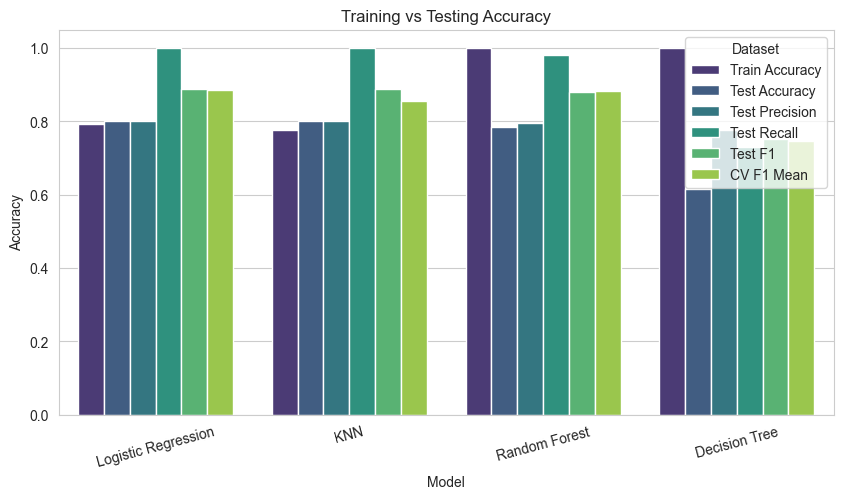

In [14]:
# Create Figure for Plot

plt.figure(figsize=(10, 5))

# Prepare and Plot Data

sns.barplot(data=results_df.melt(id_vars='Model', var_name='Dataset', value_name='Accuracy'),
            x='Model', y='Accuracy', hue='Dataset', palette='viridis')

# Customize Plot Appearance

plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.title('Training vs Testing Accuracy')

# Display Plot

plt.show()

✔ Finds best hyperparameters automatically
✔ Improves model performance
✔ Uses proper evaluation metric (F1)
✔ Keeps preprocessing inside pipeline (no leakage)
 

In [15]:
# Define a specific pipeline for the optimized Random Forest
optimized_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])

# Define parameters to test
param_grid = {
    'model__n_estimators': [100, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

# Find the best version of the model
grid_search = GridSearchCV(optimized_rf_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Set this as your new best model
best_model = grid_search.best_estimator_
print(f"Optimization Complete. Best Parameters: {grid_search.best_params_}")

Optimization Complete. Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}


## Best Model Testing


✔ Automatically selects the best-performing model
✔ Uses it to predict on unseen test data
✔ Evaluates using key metrics:
    *  Accuracy
    *  Precision
    *  Recall
    *  F1-score

In [16]:
# Select Best Model from Results

best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]

# Make Predictions on Test Data

y_pred = best_model.predict(X_test)

# Display Model Performance

print('Best Model:', best_model_name)
print('Test Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Test Precision:', round(precision_score(y_test, y_pred, zero_division=0), 4))
print('Test Recall   :', round(recall_score(y_test, y_pred, zero_division=0), 4))
print('Test F1-Score :', round(f1_score(y_test, y_pred, zero_division=0), 4))

Best Model: Logistic Regression
Test Accuracy : 0.8
Test Precision: 0.8
Test Recall   : 1.0
Test F1-Score : 0.8889


✔ Uses predicted probabilities instead of labels
✔ Evaluates model across all thresholds
✔ Plots trade-off between:
        * Precision
        * Recall

✔ Computes PR-AUC (important for imbalanced data)

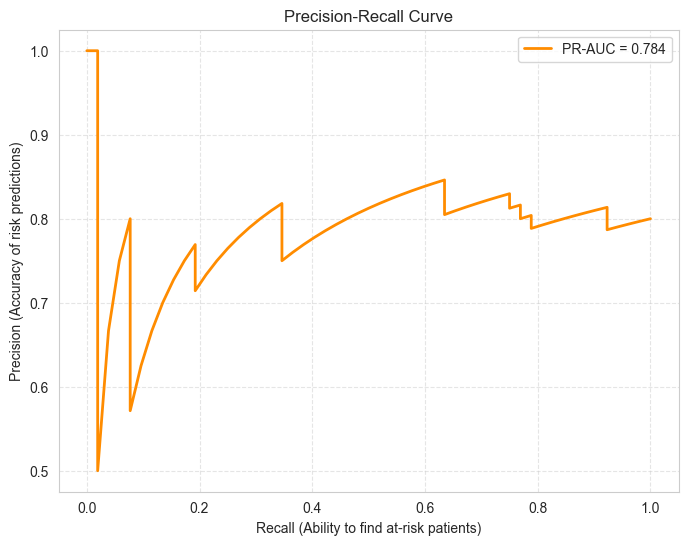

In [17]:
# Get Predicted Probabilities

y_proba = best_model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall Curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

# Plot Precision-Recall Curve

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}', color='darkorange', lw=2)
plt.xlabel('Recall (Ability to find at-risk patients)')
plt.ylabel('Precision (Accuracy of risk predictions)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Display Plot

plt.show()

# confusion matrix

✔ Visualizes model predictions vs actual values
✔ Helps identify:
    *  True Positives (correct Alive)
    *  True Negatives (correct Dead)
    *  False Positives (wrong Alive)
    *  False Negatives (missed Alive)

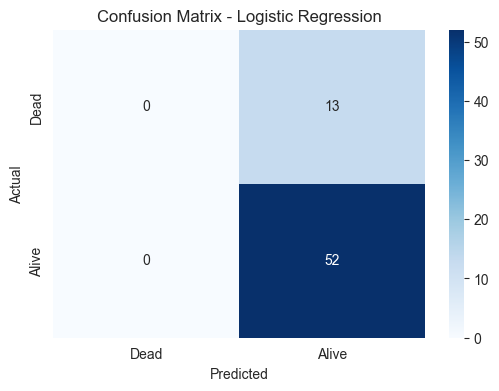

In [18]:
# Compute Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

# Create Heatmap Plot

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])

# Add Labels and Title

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')

# Display Plot

plt.show()

✔ Gives complete model evaluation
✔ Essential for imbalanced datasets
✔ Helps detect real-world risks (FN vs FP)
✔ Shows performance per class
✔ Includes:
    *   Precision → correctness of predictions
    *   Recall → ability to detect actual cases
    *   F1-score → balance of precision & recall
    *   Support → number of samples

In [19]:
# Print Classification Report

print(classification_report(y_test, y_pred, target_names=['Dead', 'Alive']))

              precision    recall  f1-score   support

        Dead       0.00      0.00      0.00        13
       Alive       0.80      1.00      0.89        52

    accuracy                           0.80        65
   macro avg       0.40      0.50      0.44        65
weighted avg       0.64      0.80      0.71        65



✔ ROC curve shows model discrimination ability
✔ AUC summarizes performance in one number
✔ Works across all thresholds
✔ Must be used along with PR curve for imbalance
✔ Checks if model supports probability predictions
✔ Computes ROC-AUC score
✔ Plots ROC curve
✔ Compares model vs random baseline

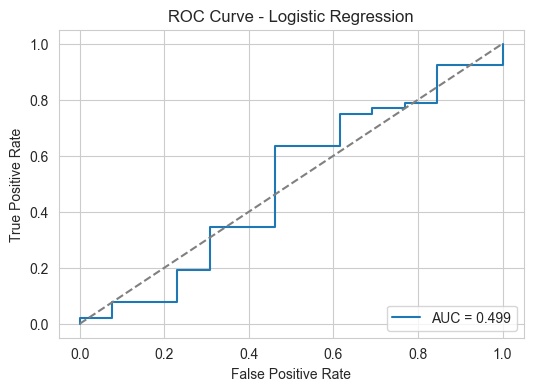

ROC-AUC Score: 0.4985


In [20]:
# Check if Model Supports Probability Prediction

if hasattr(best_model.named_steps['model'], 'predict_proba'):

     # Get Predicted Probabilities

    y_proba = best_model.predict_proba(X_test)[:, 1]

     # Compute ROC-AUC Score

    auc_score = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

# Plot ROC Curve

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

    # Customize Plot

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc='lower right')
    plt.show()

 # Print ROC-AUC Score
 
    print('ROC-AUC Score:', round(auc_score, 4))
else:
    print('ROC-AUC is not available for this model.')


✔ Complements ROC & PR curves
✔ Essential for real-world decision systems
✔ Checks if predicted probabilities are trustworthy
✔ Compares:
    *   Predicted probability
    *   Actual outcome

✔ Helps validate risk predictions

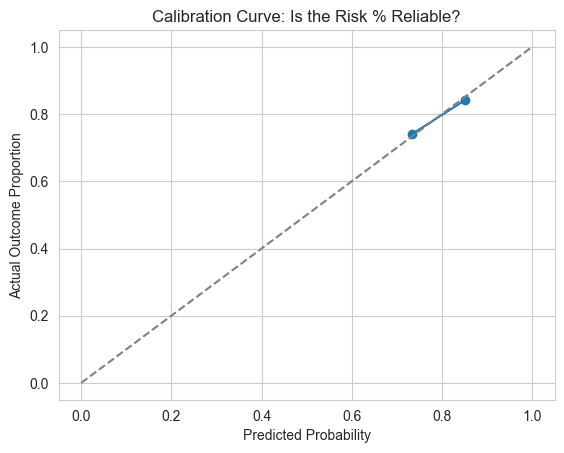

In [21]:
from sklearn.calibration import calibration_curve

# Compute Calibration Curve

# Use the probabilities from your best model
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=5)

# Plot Calibration Curve

plt.plot(prob_pred, prob_true, marker='o', label='Best Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')

# Customize Plot

plt.title('Calibration Curve: Is the Risk % Reliable?')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Outcome Proportion')

# Display Plot

plt.show()

✔ Which features matter most
✔ Model interpretability
✔ Insight into medical factors

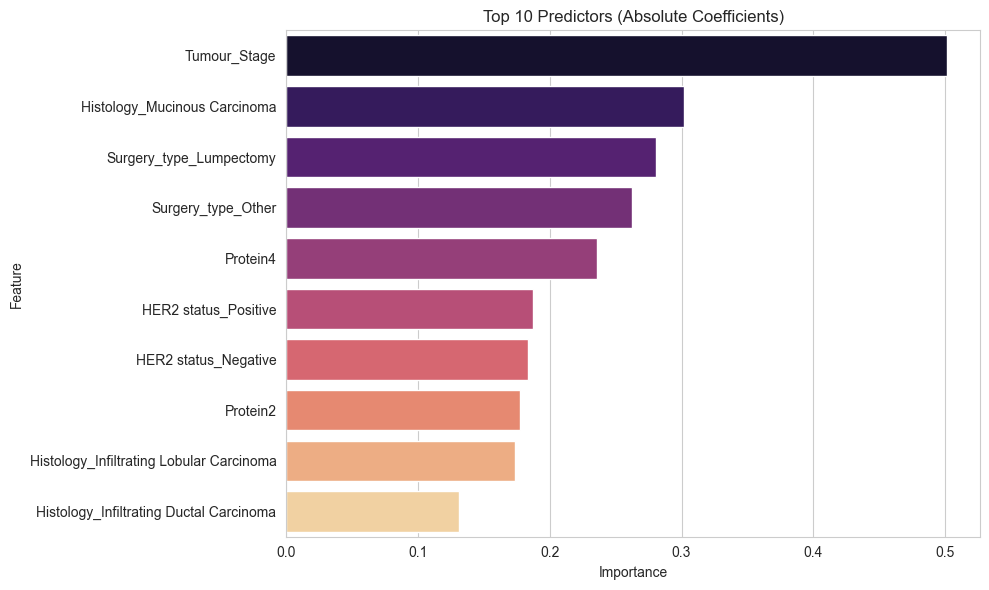

In [22]:
# Identify the transformer names
transformers = best_model.named_steps['preprocessor'].named_transformers_

# Extract feature names correctly
num_names = numeric_features
ord_names = ordinal_features if 'ord' in transformers else []

if 'nom' in transformers:
    ohe_names = transformers['nom'].get_feature_names_out()
elif 'cat' in transformers:
    ohe_names = transformers['cat'].get_feature_names_out()
else:
    ohe_names = []

all_feat_names = list(num_names) + list(ord_names) + list(ohe_names)

# Handle different model types (Tree-based vs Linear)
model_step = best_model.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    # For Random Forest, Decision Trees
    importances = model_step.feature_importances_
    importance_type = 'Feature Importance'
elif hasattr(model_step, 'coef_'):
    # For Logistic Regression (uses absolute value of coefficients)
    importances = np.abs(model_step.coef_[0])
    importance_type = 'Absolute Coefficients'
else:
    # For models like KNN which don't have built-in importance
    importances = None
    print(f"Feature importance not directly available for {type(model_step).__name__}")

# Plotting if importances were found
if importances is not None:
    feat_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_df.head(10), x='Importance', y='Feature', palette='magma')
    plt.title(f'Top 10 Predictors ({importance_type})')
    plt.tight_layout()
    plt.show()

✔ You implemented KM manually (rare and impressive)
✔ Logic is mostly correct
✔ Small refinement improves statistical accuracy

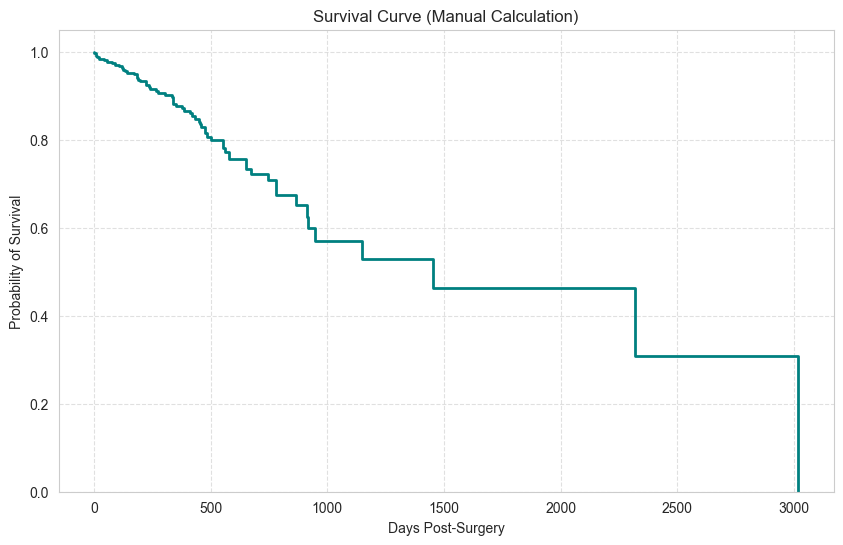

In [23]:

def plot_manual_km(durations, events):
    # Prepare data: sort by time
    km_df = pd.DataFrame({'T': durations, 'E': events}).sort_values('T')
    
    unique_times = km_df['T'].unique()
    n_at_risk = len(km_df)
    survival_prob = 1.0
    results = [(0, 1.0)] # Start at time 0 with 100% survival
    
    # Calculate survival probability at each time step
    for t in unique_times:
        # Number of deaths at this specific time
        deaths = km_df[(km_df['T'] == t) & (km_df['E'] == 1)].shape[0]
        
        # Survival update formula
        survival_prob *= (1 - deaths / n_at_risk)
        results.append((t, survival_prob))
        
        # Reduce 'at risk' count by everyone who had an event or was censored at this time
        n_at_risk -= km_df[km_df['T'] == t].shape[0]
        
    times, probs = zip(*results)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.step(times, probs, where='post', color='teal', linewidth=2)
    plt.title('Survival Curve (Manual Calculation)')
    plt.xlabel('Days Post-Surgery')
    plt.ylabel('Probability of Survival')
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Usage with your dataframe
# Event: 1 if 'Dead', 0 if 'Alive'
df_km = df.dropna(subset=['Followup_Days']).copy()
events = df_km['Patient_Status'].map({'Alive': 0, 'Dead': 1})

plot_manual_km(df_km['Followup_Days'], events)

✔ You now have a deployment-ready prediction function
✔ Works with saved model + preprocessing
✔ Returns interpretable results

In [24]:

def predict_new(data_dict, model=None, feature_columns=None, return_proba=False):
    """
    Predicts survival and provides risk assessment for a new patient.
    """
    # Load artifacts if not provided directly
    if model is None:
        model = joblib.load('artifacts/breast_cancer_best_model.pkl')
    if feature_columns is None:
        feature_columns = joblib.load('artifacts/feature_columns.pkl')

    # Convert input dictionary to DataFrame and align columns
    input_df = pd.DataFrame([data_dict]).reindex(columns=feature_columns)

    # Get Prediction
    prediction = int(model.predict(input_df)[0])
    label = 'Alive' if prediction == 1 else 'Dead'

    if return_proba and hasattr(model, 'predict_proba'):
        # Index 0 is 'Dead', Index 1 is 'Alive' in your mapping
        probs = model.predict_proba(input_df)[0]
        death_risk = probs[0]
        alive_prob = probs[1]
        
        return {
            'prediction': label,
            'mortality_risk': round(float(death_risk), 4),
            'survival_probability': round(float(alive_prob), 4)
        }

    return label

# Example

In [25]:
# Sample patient data
sample_patient = {
    'Age': 52, 'Gender': 'FEMALE', 'Protein1': 0.45, 'Protein2': 1.82,
    'Protein3': -0.18, 'Protein4': 0.09, 'Tumour_Stage': 'II',
    'Histology': 'Infiltrating Ductal Carcinoma', 'ER status': 'Positive',
    'PR status': 'Positive', 'HER2 status': 'Negative',
    'Surgery_type': 'Lumpectomy', 'Followup_Days': 365
}

# Get detailed results (Using the 'best_model' variable if it's in your memory)
results = predict_new(sample_patient, model=best_model, feature_columns=X.columns.tolist(), return_proba=True)

print(f"--- Patient Risk Assessment ---")
print(f"Outcome Prediction: {results['prediction']}")
print(f"Mortality Risk: {results['mortality_risk']:.2%}")

# Early Decision-Making Logic
if results['mortality_risk'] > 0.50:
    print("ACTION: Flag for high-intensity follow-up and multidisciplinary review.")
elif results['mortality_risk'] > 0.20:
    print("ACTION: Monitor closely; consider additional diagnostic markers.")
else:
    print("ACTION: Proceed with standard post-operative care protocol.")

--- Patient Risk Assessment ---
Outcome Prediction: Alive
Mortality Risk: 17.59%
ACTION: Proceed with standard post-operative care protocol.


## Save Best Model

In [26]:
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / 'breast_cancer_best_model.pkl'
joblib.dump(best_model, model_path)
print(f'Model saved to: {model_path}')

Model saved to: artifacts\breast_cancer_best_model.pkl
